this is just an experiment to check if HRM will overfit on a small training set. it does.

In [10]:
import os
import sys
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

torch.manual_seed(8008135)

NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

print("CODE_DIR:", CODE_DIR)
print("CODE_DIR contents:", os.listdir(CODE_DIR))

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device set to {device}")

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

CODE_DIR: /home/daniel/HRM_Reconstruction/code
CODE_DIR contents: ['.GPT2_Model', 'Utils', 'HRM_Model', 'Datasets', '.DS_Store', 'BiLSTM_Model', 'Sudoku', 'BERT_Model']
Device set to cuda


In [11]:
from Sudoku.sudoku import print_sudoku_comparison

from Datasets.Sudoku_DataLoader import get_loaders

from HRM_Model.HRM_Model import HRM
from HRM_Model.HRM_Components import Encoder, HighLevel, LowLevel, Head
from HRM_Model.HRM_Train import train_hrm_deepsup

from Utils.schedules import cosine_schedule_with_warmup_lr_lambda
from Utils.checkpointing import load_checkpoint
from Utils.visualization import show_sudoku_predictions

In [12]:
train_size = 2**7
test_size = 2**5
batch_size = 2**4

train_dataloader, val_dataloader = get_loaders(
    train_size=train_size,
    test_size=test_size,
    batch_size=batch_size,
)

Map: 100%|██████████| 32/32 [00:00<00:00, 10498.88 examples/s]


In [13]:
# Model hyperparameters
d_model = 512
M = 8
N = 2
T = 2
n_layers = 4
n_heads = 8
vocab_size = 10
dropout = 0

# Training hyperparameters
lr = 1e-4
min_lr_ratio = 0.1 # -> 1e-5
lr_warmup = 0.05
beta1 = 0.9
beta2 = 0.95
weight_decay = 0.1
num_epochs = 20 # takes ~ 1 day on my 5080

checkpoint_dir = "checkpoints"

In [14]:
high_level = HighLevel(
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    intermediate_size=4 * d_model,
    dropout=dropout,
)

low_level = LowLevel(
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    intermediate_size=4 * d_model,
    dropout=dropout,
)

encoder = Encoder(
    vocab_size=vocab_size,
    d_model=d_model,
)

head = Head(
    d_model=d_model,
    vocab_size=vocab_size,
)

HRM_model = HRM(
    L_module=low_level,
    H_module=high_level,
    encoder=encoder,
    head=head,
    M=M,
    N=N,
    T=T,
    max_len=81,
    d_model=d_model,
).to(device)

print(
    "Number of trainable parameters:",
    f"{sum(p.numel() for p in HRM_model.parameters() if p.requires_grad):,}",
)

Number of trainable parameters: 33,572,864


In [15]:
optimizer = optim.AdamW(
    HRM_model.parameters(),
    lr=lr,
    betas=(beta1, beta2),
    weight_decay=weight_decay,
)

num_training_steps = len(train_dataloader) * num_epochs * M
num_warmup_steps = int(lr_warmup * num_training_steps)

# linear warmup from 0 to 1e-4
# then cosine from 1e-4 to 1e-5
# paper claims to not use that cosine part, but they do on their github
# also we found it empirically works much better
scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda step: cosine_schedule_with_warmup_lr_lambda(
        step,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
        min_ratio=min_lr_ratio
    ),
)

print("num_training_steps:", num_training_steps)
print("num_warmup_steps:", num_warmup_steps)

num_training_steps: 1280
num_warmup_steps: 64


In [16]:
HRM_model, best_metric, history = train_hrm_deepsup(
    model=HRM_model,
    train_loader=train_dataloader,
    optimizer=optimizer,
    loss_fn=nn.CrossEntropyLoss(ignore_index=-100),
    device=device,
    scheduler=scheduler,
    num_epochs=num_epochs,
    checkpoint_dir=checkpoint_dir,
    checkpoint_every=5, 
    validate_every=5, # better validation on 2^15 examples every 5 epochs
    val_loader=val_dataloader,
    step_val_every=8,
    step_val_batches=1, # 1 batch validation every 8 steps just for logging
)

HRM_model.eval()

print("Best board accuracy used for checkpointing:", best_metric)

Number of trainable parameters: 33,572,864


Epoch 1: 100%|██████████| 8/8 [00:02<00:00,  3.03it/s]


Epoch 1: Avg Train Final Loss = 2.2231, Train Token Accuracy = 12.11%, Train Board Accuracy = 0.00%, LR = 1.00e-04


Epoch 2: 100%|██████████| 8/8 [00:02<00:00,  3.02it/s]


Epoch 2: Avg Train Final Loss = 2.1236, Train Token Accuracy = 16.41%, Train Board Accuracy = 0.00%, LR = 9.94e-05


...

Epoch 19: Avg Train Final Loss = 0.0002, Train Token Accuracy = 100.00%, Train Board Accuracy = 100.00%, LR = 1.06e-05


Epoch 20: 100%|██████████| 8/8 [00:02<00:00,  3.02it/s]


Epoch 20: Avg Train Final Loss = 0.0000, Train Token Accuracy = 100.00%, Train Board Accuracy = 100.00%, LR = 1.00e-05


Validation: 100%|██████████| 2/2 [00:00<00:00,  8.80it/s]


Val Loss = 10.7990, Val Token Accuracy = 16.50%, Val Board Accuracy = 0.00%

Best board accuracy used for checkpointing: 1.0


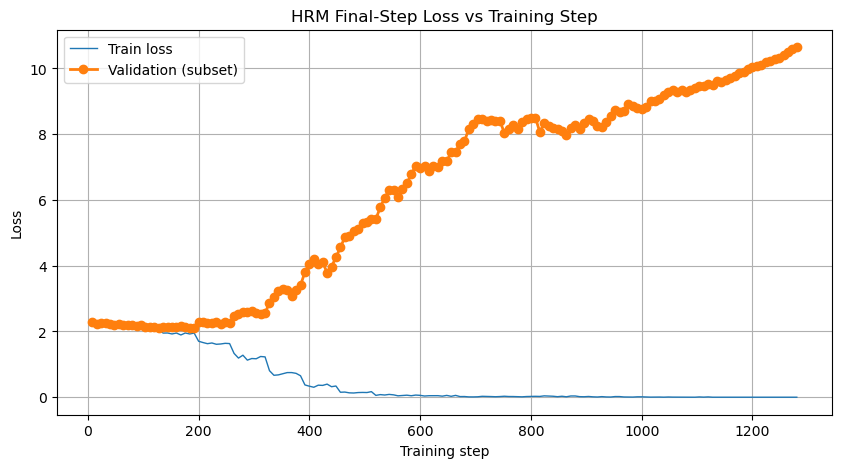

In [19]:
import matplotlib.pyplot as plt

train_steps = history["step"]
train_loss = history["train_loss"]

val_steps = [
    s for s, v in zip(history["step"], history["val_loss"])
    if v is not None
]

val_loss = [
    v for v in history["val_loss"]
    if v is not None
]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Train loss", linewidth=1)

if len(val_loss) > 0:
    plt.plot(
        val_steps,
        val_loss,
        marker="o",
        linestyle="-",
        label="Validation (subset)",
        linewidth=2,
    )

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("HRM Final-Step Loss vs Training Step")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
show_sudoku_predictions(
    HRM_model,
    val_dataloader,
    device,
    print_sudoku_comparison,
    num_examples=10,
)

Input / Prediction
5 9 8 | 6 4 1 | 2 8 6 
7 3 5 | 5 2 8 | 4 9 6 
1 6 4 | 7 2 2 | 5 8 9 
---------------------------------
8 7 3 | 3 4 6 | 1 4 2 
6 2 8 | 9 5 9 | 7 1 4 
3 6 3 | 8 1 8 | 6 5 2 
---------------------------------
4 1 2 | 9 4 7 | 3 6 9 
3 5 8 | 7 9 5 | 7 3 1 
6 8 7 | 2 3 6 | 9 1 4 

Unknown-cell token accuracy: 0.2222222238779068

Input / Prediction
5 9 8 | 4 2 1 | 6 4 3 
7 2 2 | 7 8 5 | 9 6 4 
4 6 1 | 7 1 3 | 2 5 8 
---------------------------------
2 9 4 | 1 3 5 | 9 7 8 
5 6 6 | 7 4 2 | 6 3 1 
7 2 7 | 5 8 9 | 4 5 3 
---------------------------------
6 8 2 | 9 1 3 | 5 9 4 
1 6 6 | 8 2 7 | 8 2 5 
4 2 3 | 9 4 1 | 5 7 6 

Unknown-cell token accuracy: 0.12962962687015533

Input / Prediction
8 3 2 | 7 4 8 | 7 5 1 
2 6 5 | 9 1 3 | 2 6 8 
2 4 8 | 5 2 6 | 9 1 5 
---------------------------------
4 3 7 | 6 1 8 | 8 2 3 
2 9 1 | 5 4 5 | 9 8 6 
7 1 2 | 3 9 2 | 4 1 5 
---------------------------------
9 6 4 | 5 3 6 | 2 7 8 
2 8 1 | 6 7 4 | 4 3 9 
3 5 8 | 2 3 1 | 6 7 4 

Unknown-cell tok